In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import fetch_california_housing

# Data Preprocessing
from sklearn.preprocessing import StandardScaler

# Splitting Dataset
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor

# Model Evaluation
from sklearn.metrics import mean_squared_error, r2_score

In [2]:

# Load California Housing Dataset
housing = fetch_california_housing()

# Create DataFrame for Features
X = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

# Create Target Column
y = pd.Series(
    housing.target,
    name="HousePrice"
)

# Combine Features and Target
df = pd.concat([X, y], axis=1)

print("Dataset Loaded Successfully!\n")

# Display first five rows
df.head()

Dataset Loaded Successfully!



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
housing = fetch_california_housing()

In [4]:
X = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

In [5]:
y = pd.Series(
    housing.target,
    name="HousePrice"
)

In [6]:
df = pd.concat([X, y], axis=1)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [10]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

Ridge()

In [11]:
tree = DecisionTreeRegressor(max_depth=5, random_state=42)
tree.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [12]:

# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

# Decision Tree Regression
tree_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=5
)

tree_model.fit(X_train, y_train)

print("All models trained successfully!")

All models trained successfully!


In [14]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Dictionary containing all models
models = {
    "Linear Regression": linear_model,
    "Ridge Regression": ridge_model,
    "Decision Tree": tree_model
}

# Store results
results = []

# Evaluate each model
for name, model in models.items():

    # Make predictions
    predictions = model.predict(X_test)

    # Calculate metrics
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    # Save results
    results.append([name, mae, rmse, r2])

# Create comparison table
results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R² Score"]
)

results_df

,Model,MAE,RMSE,R² Score
0,Linear Regression,0.533200,0.745581,0.575788
1,Ridge Regression,0.533193,0.745554,0.575819
2,Decision Tree,0.522259,0.724234,0.599732


In [15]:
# Find the best model based on R² Score

best_model = results_df.loc[results_df["R² Score"].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Model       Decision Tree
MAE              0.522259
RMSE             0.724234
R² Score         0.599732
Name: 2, dtype: object


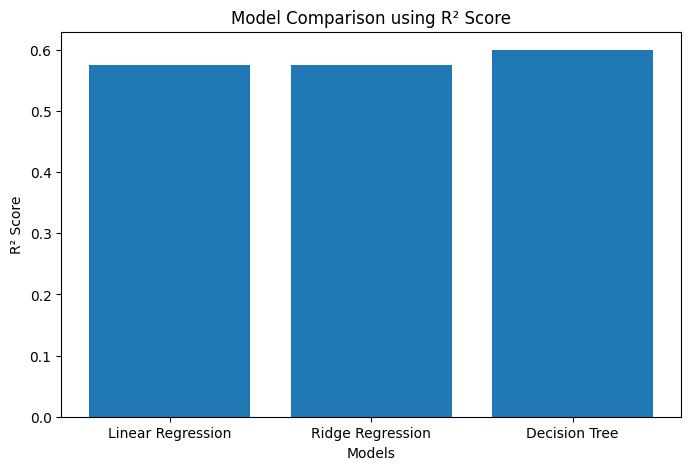

In [16]:
# Plot R² Score comparison

plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["R² Score"])

plt.title("Model Comparison using R² Score")
plt.xlabel("Models")
plt.ylabel("R² Score")

plt.show()

## Conclusion

Three regression models were trained and evaluated on the California Housing dataset.

Among them, **Decision Tree Regressor** achieved the highest R² Score and the lowest prediction error on this dataset. Therefore, it was selected as the best-performing model for this project.

This comparison demonstrates how evaluating multiple models helps in selecting the most suitable algorithm for a regression task.

